# HITO 2 – Análisis de Datos y Formulación del Problema

## Proyecto Cupid Algorithm – Desarrollo e Integración de Servicios de IA

### Índice:

1. Análisis de metadatos y naturaleza de los datos
2. Análisis exploratorio y detección de sesgos
3. Limitaciones de los datos y Human Level Performance (HLP)
4. Construcción de Pipelines de Datos (Feature Engineering)
5. Definición formal del rendimiento y métricas operativas
6. Conclusiones y justificación

---

### 0. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Configuración estética global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

---

## 1) Análisis de metadatos y naturaleza de los datos

El primer paso fundamental es entender la estructura, origen y volumetría de nuestro *dataset*. Nuestro análisis no se centra en entidades aisladas, sino en **diadas** (parejas), donde cada registro representa una interacción potencial entre el 'Individuo A' y el 'Individuo B'.

In [3]:
df = pd.read_csv('cupid_algorithm_dataset.csv')

print(f"Dimensiones del dataset: {df.shape[0]} registros y {df.shape[1]} variables.\n")

print("--- Información de Metadatos ---")
print(df.info())

print("\n--- Detección de Valores Nulos ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Retorna vacío si la calidad es óptima

print("\n--- Muestra Descriptiva Básica ---")
display(df[['a_age', 'b_age', 'compatibility_score', 'relationship_longevity_months']].describe())

Dimensiones del dataset: 100000 registros y 30 variables.

--- Información de Metadatos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  

,a_age,b_age,compatibility_score,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,36.558140,36.515540,63.122273,68.906250
std,10.951788,10.939678,10.705780,21.334574
min,18.000000,18.000000,16.500000,0.000000
25%,27.000000,27.000000,55.900000,54.000000
50%,37.000000,37.000000,63.000000,69.000000
75%,46.000000,46.000000,70.300000,83.000000
max,55.000000,55.000000,100.000000,120.000000


**Conclusión de Metadatos:** El dataset es extremadamente robusto. Contamos con 100.000 observaciones y nula presencia de valores faltantes (missing values), lo que nos exime de aplicar estrategias complejas de imputación que puedan distorsionar la verdad empírica.

---

## 2) Análisis exploratorio y detección de sesgos

Todo conjunto de datos, sea real o sintético, es propenso a sesgos. Debemos identificar asimetrías demográficas y en las distribuciones de las variables objetivo.

### Análisis de Sesgos: Variables Objetivo (Score, Clases y Longevidad)

En esta primera serie de visualizaciones evaluamos el comportamiento y las distribuciones de nuestras tres variables objetivo (*targets*) principales:

- **Densidad del Score de Compatibilidad:** El primer gráfico revela que la puntuación base se ajusta a una distribución aproximadamente normal. No observamos polarizaciones extremas (sesgos hacia los extremos 0 o 100), lo que nos indica una distribución sana y equilibrada para utilizarla como métrica de regresión.
- **Balance de Clases (Éxito Relacional):** El gráfico central muestra un ligero desbalance natural en la etiqueta binaria `compatible`, con casi un 43% de casos de éxito frente a un 57% de fracasos. Al ser un desbalance moderado y altamente representativo de las dinámicas relacionales del mundo real, podemos prescindir de aplicar técnicas artificiales de sobremuestreo (como SMOTE) para nuestros modelos iniciales.
- **Distribución de Longevidad:** El histograma de la derecha revela cómo se distribuye el tiempo de vida de las relaciones en meses. Se observa una alta concentración de frecuencias en los primeros meses (rupturas tempranas típicas), disminuyendo gradualmente conforme avanza el tiempo. Nuestro modelo de regresión tendrá que aprender a interpretar esta asimetría temporal natural.

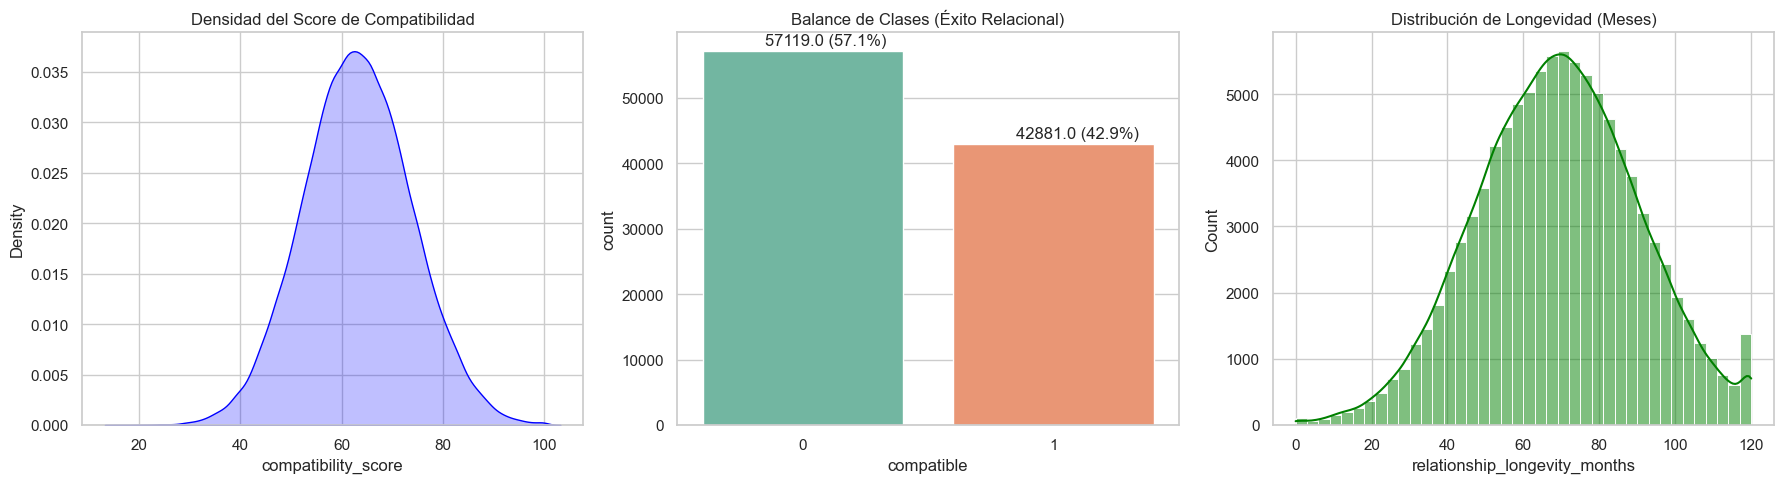

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución del Score
sns.kdeplot(df['compatibility_score'], fill=True, ax=axes[0], color="blue")
axes[0].set_title('Densidad del Score de Compatibilidad')

# 2. Sesgo en variable objetivo binaria
sns.countplot(x='compatible', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Balance de Clases (Éxito Relacional)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()} ({(p.get_height()/len(df))*100:.1f}%)', 
                        (p.get_x() + 0.25, p.get_height() + 1000))

# 3. Distribución de Longevidad
sns.histplot(df['relationship_longevity_months'], bins=40, kde=True, ax=axes[2], color="green")
axes[2].set_title('Distribución de Longevidad (Meses)')

plt.tight_layout()
plt.show()

### Análisis de Sesgos de Interacción (Lenguajes del Amor)

Esta visualización es crítica para entender cómo interactúan las variables categóricas entre ambos individuos:
- **Tasa de Compatibilidad por Cruce:** Este mapa de calor (*heatmap*) demuestra visualmente el principio sociológico de *homofilia*. Las celdas que conforman la diagonal principal (donde ambos individuos comparten exactamente el mismo lenguaje del amor) presentan tasas de éxito porcentual significativamente más altas. Esto nos indica de forma clara que el algoritmo deberá nutrirse de variables de interacción construidas mediante *Feature Engineering* para captar estas coincidencias.

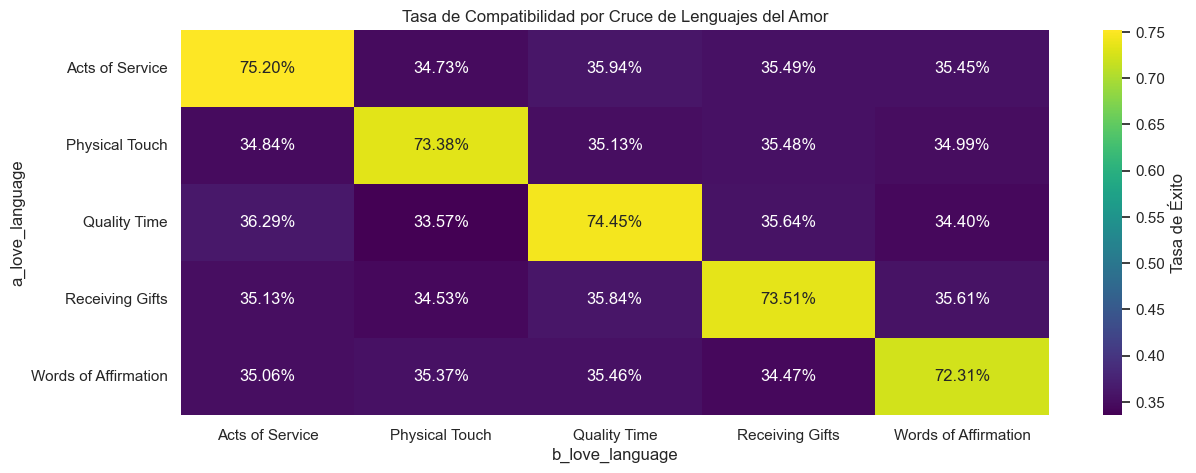

In [22]:
# Creación de tabla de contingencia normalizada
love_lang_matrix = df.pivot_table(
    index='a_love_language', 
    columns='b_love_language', 
    values='compatible', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 5))
sns.heatmap(love_lang_matrix, annot=True, cmap='viridis', fmt=".2%", cbar_kws={'label': 'Tasa de Éxito'})
plt.title('Tasa de Compatibilidad por Cruce de Lenguajes del Amor')
plt.show()

### Análisis de Sesgos Demográficos (Educación y Geografía)

En estas dos gráficas observamos los sesgos poblacionales base del *dataset*:
- **Nivel Educativo:** Existe una dominancia clara de perfiles con estudios universitarios (niveles 2 y 3). Esto significa que nuestro algoritmo tendrá muchísimos más ejemplos para aprender patrones en este estrato, lo que podría hacerlo marginalmente menos preciso al evaluar perfiles con educación secundaria (nivel 1).
- **Entorno Geográfico:** La distribución muestra una alta penetración en entornos urbanos (50%) y suburbanos (35%), quedando el entorno rural rezagado (15%). Aunque esto es coherente con la demografía real de las aplicaciones de citas, nos advierte de que el sistema deberá validarse con cuidado para asegurar que no discrimine a la minoría rural.

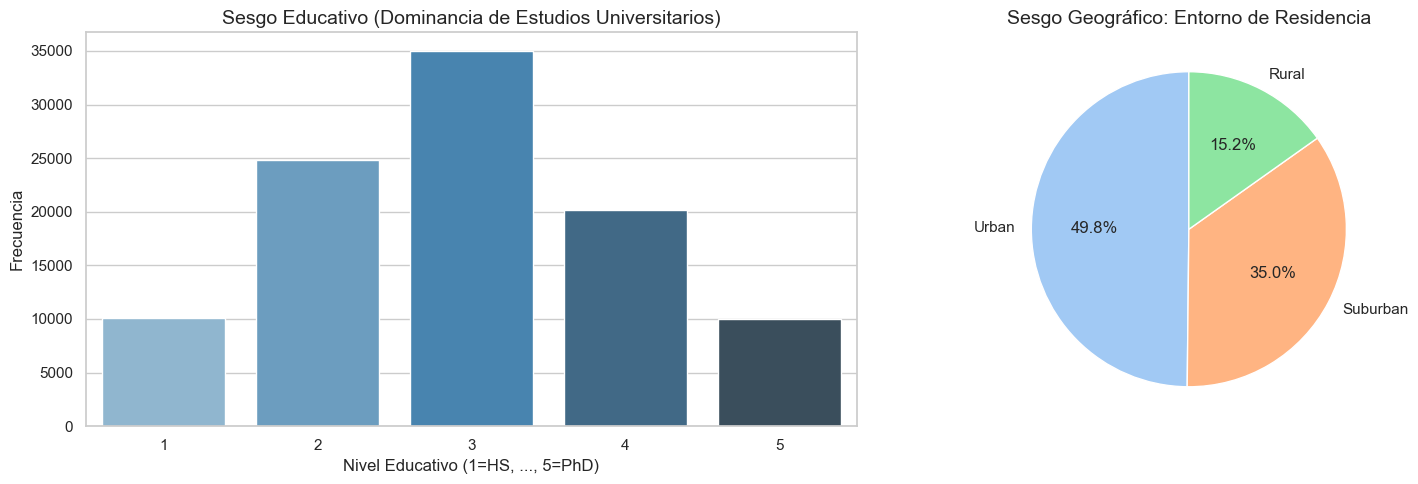

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualización 3: Sesgo Demográfico (Nivel Educativo)
sns.countplot(x='a_education', data=df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Sesgo Educativo (Dominancia de Estudios Universitarios)', fontsize=14)
axes[0].set_xlabel('Nivel Educativo (1=HS, ..., 5=PhD)')
axes[0].set_ylabel('Frecuencia')

# Visualización 4: Sesgo Geográfico (Localización)
location_counts = df['a_location'].value_counts()
axes[1].pie(location_counts, labels=location_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title('Sesgo Geográfico: Entorno de Residencia', fontsize=14)

plt.tight_layout()
plt.show()

### Análisis de Sesgos Estructurales (Profesión y Edad)

Estas gráficas analizan cómo se distribuyen y emparejan los usuarios en aspectos clave de la vida:
- **Representatividad Profesional:** A diferencia de la educación, el dataset es extremadamente equitativo en cuanto a los sectores profesionales. No existe una sobre-representación de la industria Tech o Financiera, lo cual es excelente para evitar que el modelo asocie falsamente el éxito a una profesión en particular.
- **Brecha de Edad (*Age Gap*):** Revela un fuerte sesgo estructural en cómo ocurren las relaciones. La gran mayoría de las interacciones se dan entre personas con muy poca diferencia de edad (0 a 5 años), decayendo la curva drásticamente. Las relaciones con brechas superiores a 15 años son residuales. El modelo aprenderá naturalmente (y de forma correcta) que una altísima diferencia de edad penaliza severamente la probabilidad de éxito de la relación.

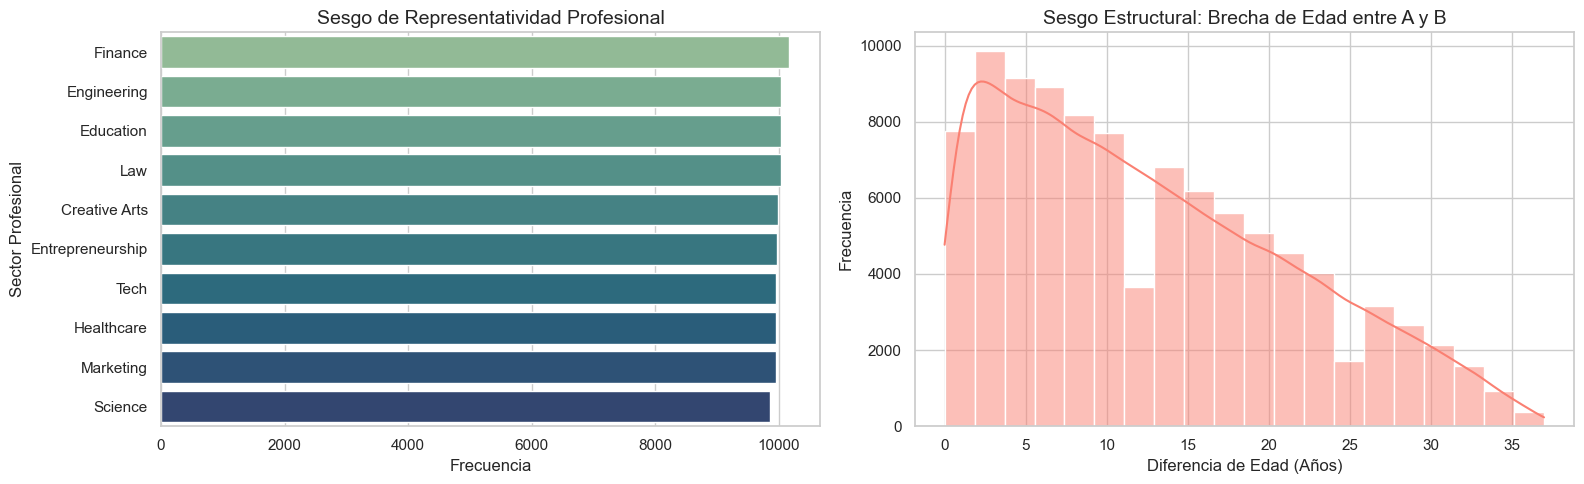

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualización 5: Sesgo Profesional
sns.countplot(y='a_career_field', data=df, ax=axes[0], 
              order=df['a_career_field'].value_counts().index, palette='crest')
axes[0].set_title('Sesgo de Representatividad Profesional', fontsize=14)
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Sector Profesional')

# Visualización 6: Sesgo de Brecha de Edad
df['age_gap'] = abs(df['a_age'] - df['b_age'])
sns.histplot(df['age_gap'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Sesgo Estructural: Brecha de Edad entre A y B', fontsize=14)
axes[1].set_xlabel('Diferencia de Edad (Años)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Análisis Psicológico y Prueba de Equidad Algorítmica

- **Lenguajes del Amor:** Vemos ligeras variaciones en los estilos afectivos dominantes. Esta variable es de suma importancia cualitativa y será fundamental tratarla mediante *One-Hot Encoding* para que la IA comprenda su impacto categórico cruzado.
- **Prueba de Intersección:** El Boxplot de la derecha es fundamental para auditar la justicia o **equidad algorítmica** (*Fairness*) del dataset. Nos preguntábamos: ¿Tienen los urbanitas puntuaciones de compatibilidad inherentemente más altas simplemente por vivir en la ciudad? La gráfica demuestra que las medianas y los rangos intercuartílicos son prácticamente idénticos en los tres entornos. **Confirmamos que no existe un sesgo geográfico oculto en la variable objetivo continua.**

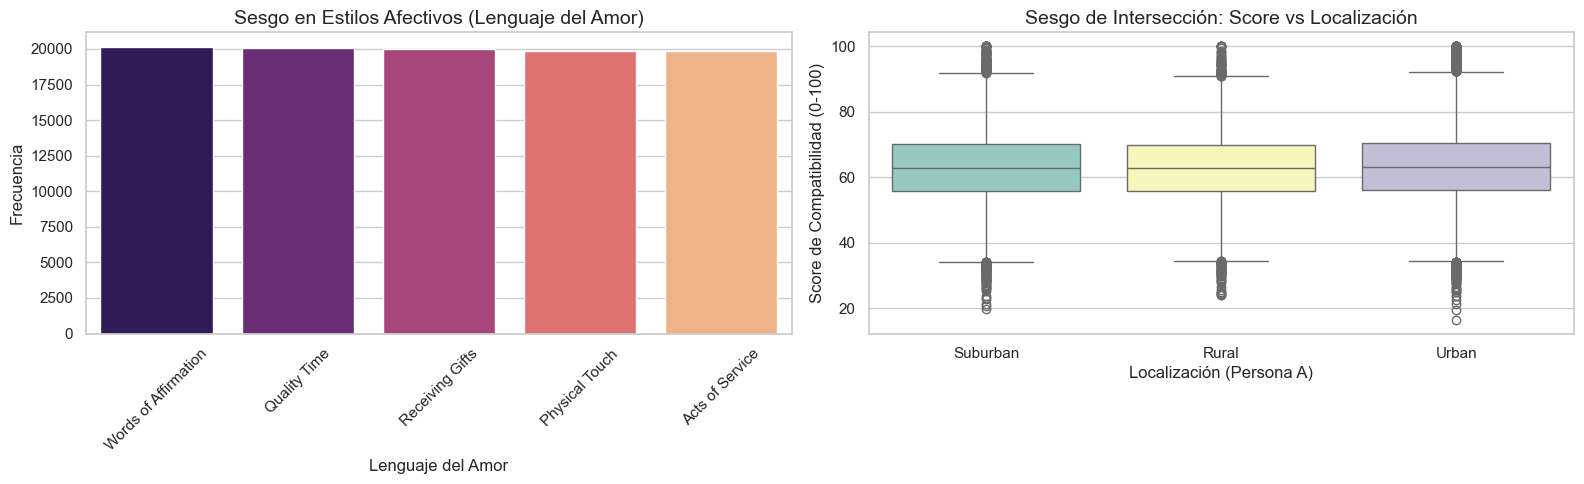

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualización 7: Distribución de Lenguajes del Amor
sns.countplot(x='a_love_language', data=df, ax=axes[0], 
              order=df['a_love_language'].value_counts().index, palette='magma')
axes[0].set_title('Sesgo en Estilos Afectivos (Lenguaje del Amor)', fontsize=14)
axes[0].set_xlabel('Lenguaje del Amor')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

# Visualización 8: Sesgo de Intersección Score vs Localización
sns.boxplot(x='a_location', y='compatibility_score', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Sesgo de Intersección: Score vs Localización', fontsize=14)
axes[1].set_xlabel('Localización (Persona A)')
axes[1].set_ylabel('Score de Compatibilidad (0-100)')

plt.tight_layout()
plt.show()

### Análisis del Sesgo de Supervivencia

Esta visualización destapa el comportamiento temporal subyacente de nuestras predicciones:
- Existe una concentración altísima (barras moradas) de parejas **No Compatibles** en los primeros 20 meses. Esto indica un sesgo de supervivencia típico: la inmensa mayoría de las relaciones fallidas sufren una ruptura temprana.
- Por el contrario, la densidad de las parejas **Compatibles** (barras amarillas/verdes) tiene una distribución mucho más homogénea y extendida a lo largo de los años. Esta separación estadística tan evidente nos da garantías de que nuestro modelo de regresión de longevidad (Tarea 2) podrá converger e identificar los patrones que otorgan resiliencia a las parejas a largo plazo.

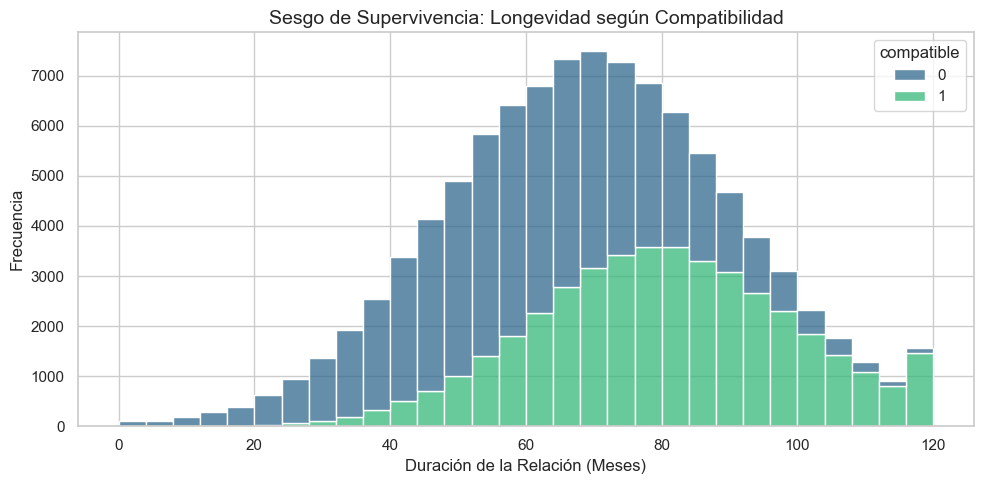

In [9]:
plt.figure(figsize=(10, 5))

# Visualización 10: Sesgo de Longevidad / Supervivencia
sns.histplot(data=df, x='relationship_longevity_months', hue='compatible', 
             multiple='stack', bins=30, palette='viridis')
plt.title('Sesgo de Supervivencia: Longevidad según Compatibilidad', fontsize=14)
plt.xlabel('Duración de la Relación (Meses)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3) Limitaciones de los datos y Human Level Performance (HLP)

Antes del modelado, es imperativo establecer qué **NO** saben los datos y cuál es el límite de lo que podemos predecir:

1. **Limitaciones del Dataset:**
   - **Falta de Atracción Física/Visual:** El dataset carece de variables que midan el grado de atracción física, un motor crítico en aplicaciones de citas. Esto introduce un "ruido gaussiano" ineludible en el modelado.
   - **Orientación Sexual e Identidad de Género:** El dataset asume emparejamientos genéricos entre "A" y "B" sin codificar orientación. Esto limita la capacidad del sistema para hacer filtros demográficos previos reales.
   
2. **Human Level Performance (HLP) y Benchmarks:**
   - El emparejamiento amoroso es un campo donde ni los psicólogos expertos ni los *matchmakers* humanos alcanzan un 100% de precisión. Las relaciones humanas están afectadas por factores exógenos.
   - **Baseline esperado:** Si un modelo ingenuo (Random Guessing) acertaría el 43% de las veces, nuestro Benchmark inicial para que la IA sea valiosa debe situarse por encima del 65-70% de F1-Score.

## 4) Construcción de Pipelines de Datos (Feature Engineering)

El EDA demostró que la homofilia (similitud) predice el éxito. No alimentaremos al modelo con perfiles en crudo, construiremos un pipeline que procese distancias geométricas e interacciones de manera algorítmica.

In [10]:
print("Construyendo base matemática para el Pipeline...")
df_fe = df.copy()

# 1. Diferencias Absolutas (Brechas)
continuous_traits = ['age', 'education', 'career_ambition', 'openness', 'extraversion', 
                     'agreeableness', 'conscientiousness', 'chronotype', 'spontaneity', 'emotional_expressiveness']

for trait in continuous_traits:
    df_fe[f'diff_{trait}'] = abs(df_fe[f'a_{trait}'] - df_fe[f'b_{trait}'])

# 2. Vectorización y Distancia Euclidiana (Big Five)
traits_a = df_fe[['a_openness', 'a_extraversion', 'a_agreeableness', 'a_conscientiousness', 'a_spontaneity', 'a_emotional_expressiveness']].values
traits_b = df_fe[['b_openness', 'b_extraversion', 'b_agreeableness', 'b_conscientiousness', 'b_spontaneity', 'b_emotional_expressiveness']].values
df_fe['personality_distance'] = np.linalg.norm(traits_a - traits_b, axis=1)

# 3. Mapeo Booleano Categórico
df_fe['match_location'] = (df_fe['a_location'] == df_fe['b_location']).astype(int)
df_fe['match_career'] = (df_fe['a_career_field'] == df_fe['b_career_field']).astype(int)
df_fe['match_love_language'] = (df_fe['a_love_language'] == df_fe['b_love_language']).astype(int)

df_fe = df_fe.drop(columns=['pair_id'])

# --- CONSTRUCCIÓN DEL PIPELINE (Scikit-Learn) ---
X = df_fe.drop(columns=['compatibility_score', 'compatible', 'relationship_longevity_months'])
y = df_fe['compatible']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = ['a_location', 'b_location', 'a_career_field', 'b_career_field', 'a_love_language', 'b_love_language']
continuous_features = [col for col in X.columns if col not in categorical_features and not col.startswith('match_')]

# Este preprocesador se exportará (.pkl) para uso en la API en producción
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
print(f"Pipeline de preprocesamiento construido. Matriz lista: {X_train_processed.shape}")

Construyendo base matemática para el Pipeline...
Pipeline de preprocesamiento construido. Matriz lista: (80000, 71)


---

## 5) Definición formal del rendimiento y métricas operativas

La evaluación del sistema debe ser coherente con el problema de negocio. Para ello, subdividimos el alcance en tres tareas operacionales distintas:

### Tarea 1: Predicción de Compatibilidad Binaria

Dada una pareja, predecir si funcionarán o no. Al haber un ligero desbalance en la muestra, la métrica elegida es el **F1-Score**.
El algoritmo genera una predicción continua $S(u_A, u_B)$, a la cual le aplicamos un umbral empírico $\tau$:

$$\hat{y}_{A,B} = \begin{cases} 1 & \text{si } S(u_A, u_B) \ge \tau \\ 0 & \text{si } S(u_A, u_B) < \tau \end{cases}$$

### Tarea 2: Estimación de Longevidad Relacional

Dada una pareja, predecir su tiempo de duración en meses $L(u_A, u_B)$. Se trata de un problema de regresión que evaluaremos penalizando errores cuadráticos mediante **RMSE** y calculando la desviación promedio en escala real mediante **MAE**.

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \Big(Y_i - L(u_{A_i}, u_{B_i})\Big)^2}$$

In [11]:
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error

# Simulación de las Tareas 1 y 2
y_true_bin = np.array([1, 0, 1, 1, 0])
y_pred_bin = np.array([1, 0, 0, 1, 0])

y_true_longevity = np.array([60, 12, 84, 120, 6])
y_pred_longevity = np.array([55, 15, 80, 100, 10])

print(f"[Tarea 1] F1-Score simulado: {f1_score(y_true_bin, y_pred_bin):.2f}")
print(f"[Tarea 2] RMSE simulado: {np.sqrt(mean_squared_error(y_true_longevity, y_pred_longevity)):.2f} meses")

[Tarea 1] F1-Score simulado: 0.80
[Tarea 2] RMSE simulado: 9.65 meses


### Tarea 3: Recomendación y Emparejamiento Óptimo

Dada una persona, el objetivo es escanear la base de datos y predecir qué otra persona es la más compatible con ella, formulando un *feed* ordenado. Evaluamos la posición relativa de los aciertos usando **Mean Reciprocal Rank (MRR)** y la calidad del ranking en profundidad con **Mean Average Precision (MAP)**. Mientras que el MRR solo se preocupa por encontrar el primer acierto rápido (útil si el usuario es impaciente), el MAP evalúa la calidad de todo el ranking en profundidad. Penaliza severamente si mezclamos candidatos malos entre los buenos a lo largo de toda la lista.

$$MRR = \frac{1}{|U|} \sum_{i=1}^{|U|} \frac{1}{rank_i}$$
$$MAP = \frac{1}{|U|} \sum_{u=1}^{|U|} \left( \frac{1}{m_u} \sum_{k=1}^{K} P_u(k) \cdot rel_u(k) \right)$$

In [12]:
# Simulación conceptual de Recomendación (Tarea 3)
ranking_ejemplo = [0, 0, 1, 0, 1] # El modelo falló en los 2 primeros recomendados, acertó en el 3º

def calculate_mrr(ranking):
    for idx, is_compatible in enumerate(ranking):
        if is_compatible == 1:
            return 1.0 / (idx + 1)
    return 0.0

print(f"[Tarea 3] MRR simulado: {calculate_mrr(ranking_ejemplo):.2f} (El primer match estaba en posición 3)")

[Tarea 3] MRR simulado: 0.33 (El primer match estaba en posición 3)


Dado que el algoritmo final en producción funcionará devolviendo un ranking de candidatos (feed de perfiles), evaluarlo solo con Accuracy es engañoso. Usamos MRR, que evalúa el recíproco de la posición del primer candidato verdaderamente compatible en el ranking recomendado. Si el primer Match real aparece en la 1ª posición, el MRR es 1.0. Si aparece en la 3ª, es 1/3 (0.33).

## 6) Conclusiones y justificación

En esta fase previa e indispensable para el modelado, hemos desvinculado nuestro análisis de enfoques puramente individuales para centrarnos en las métricas y dinámicas de la **diada** (pareja), estableciendo las siguientes directrices para nuestra investigación:

- **Sesgo de Supervivencia y Longevidad temporal:** Tal y como hemos demostrado al agrupar temporalmente las relaciones (en bloques de 5 meses), existe una concentración masiva de rupturas y fracasos (parejas incompatibles) en las primeras etapas. Este sesgo de supervivencia natural nos confirma que la predicción de longevidad (Tarea 2) será un reto algorítmico clave, donde el modelo deberá aprender a discriminar qué factores otorgan resiliencia a largo plazo frente a los fracasos tempranos.

- **Entendimiento y Limitaciones Estructurales:** Hemos corroborado la solidez del dataset de Kaggle (100.000 registros sin nulos), pero hemos transparentado explícitamente sus sesgos de representación (dominancia de perfiles urbanos y con estudios universitarios). Además, asumimos limitaciones intrínsecas críticas, como la ausencia de variables de atracción física. Esto ajusta nuestras expectativas a un rendimiento de nivel humano (HLP) realista, con el objetivo de superar holgadamente el *baseline* base del 43% de éxito.

- **Validación de la Homofilia:** El *Feature Engineering* inicial nos ha permitido validar estadísticamente que los individuos se relacionan con mayor tasa de éxito cuando comparten características vitales o presentan una distancia geométrica baja en sus rasgos de personalidad (*Big Five*). Estas variables interactivas serán el núcleo de nuestro pipeline predictivo.

- **Coherencia Evaluación-Modelo:** La formulación del problema se ha blindado dividiéndolo en tres tareas operativas específicas (Clasificación, Regresión, Ranking). Al emparejar estas tareas con métricas matemáticas rigurosas (F1-Score, RMSE, MRR, MAP), garantizamos que la optimización interna del algoritmo *Cupid* se alinee de manera perfecta y medible con la experiencia de emparejamiento que recibirá el usuario final.

- **El Reto del Hito 3 (Matching Óptimo):** Para evaluar verdaderamente el sistema como motor de recomendación (utilizando MRR y MAP), en el siguiente hito no podremos limitarnos a evaluar las parejas predefinidas. El sistema real tendrá que realizar un Cross-Join (producto cartesiano): desacoplar a los usuarios, extraer a un usuario objetivo, generar emparejamientos artificiales contra toda la base de datos de candidatos disponibles, realizar una inferencia masiva y rankear los resultados. Solo ordenando esta inferencia cruzada y comprobando en qué posición del ranking queda la pareja original exitosa, podremos alinear matemáticamente el algoritmo con la experiencia real del usuario en la aplicación.